# Dengue Disease Spread Prediction
Your goal is to predict the `total_cases` label for each (`city`, `year`, `weekofyear`) in the test set. There are two cities, San Juan and Iquitos, with test data for each city spanning 5 and 3 years respectively. You will make one submission that contains predictions for both cities. The data for each city have been concatenated along with a city column indicating the source: `sj` for San Juan and `iq` for Iquitos. The test set is a pure future hold-out, meaning the test data are sequential and non-overlapping with any of the training data. Throughout, missing values have been filled as NaNs.

## Data Acquisition

In [30]:
# import necessary libraries

# data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns


# Sci-kit learn tools
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

print("-----------------\nDone!")

-----------------
Done!


In [32]:
# Set the plotting style
# plt.style.use('seaborn-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [3]:
# import datasets using pandas
den_feat_train = pd.read_csv("data/dengue_features_train.csv")
den_labels_train = pd.read_csv("./data/dengue_labels_train.csv")
test_df = pd.read_csv("./data/dengue_features_test.csv")

In [4]:
# read train features data
den_feat_train.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [ ]:
# read train labels data
den_labels_train.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


In [7]:
# check the shape of the labels and features datasets
print(f"Train feat shape: {den_feat_train.shape}")
print(f"Train labels shape: {den_labels_train.shape}")

Train feat shape: (1456, 24)
Train labels shape: (1456, 4)


### Data Preparation

In [12]:
# check if column 'year' of both feature and labels are the same
if den_labels_train['year'].equals(den_feat_train['year']):
    print("They are the same")
else:
    print("The are not the same!")

They are the same


In [15]:
# Assign id index to both dataframes
den_labels_train["id"] = den_labels_train.index + 1
den_feat_train["id"] = den_feat_train.index + 1

In [16]:
# check if 'id' column exists in both dataframes
if den_feat_train['id'].equals(den_labels_train['id']):
    print("id column exists in both dataframes")
else:
    print("id column does not exist in both dataframes")

id column exists in both dataframes


In [19]:
# Set 'id' as index
den_feat_train.index = den_feat_train['id']
den_labels_train.index = den_labels_train['id']
den_feat_train.drop(columns=['id'], inplace=True)
den_labels_train.drop(columns=['id'], inplace=True)
den_feat_train.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
id,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
2,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
3,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
4,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
5,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [20]:
# Let's merge the two dataframes to form 'one' train dataframe
train_df = pd.merge(den_labels_train, den_feat_train, on="id", how="inner")
print(f"Shape: {train_df.shape}")
train_df.head()

Shape: (1456, 28)


,city_x,year_x,weekofyear_x,total_cases,city_y,year_y,weekofyear_y,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
2,sj,1990,19,5,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
3,sj,1990,20,4,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
4,sj,1990,21,3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
5,sj,1990,22,6,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [22]:
# Let's drop the duplicated columns
train_df.drop(columns=['city_y', "year_y", "weekofyear_y"], inplace=True)
print(train_df.shape)

(1456, 25)


In [23]:
# Let's rename columns by removing the x suffixes
train_df.columns = train_df.columns.str.replace("_x", "")
print(train_df.columns)

Index(['city', 'year', 'weekofyear', 'total_cases', 'week_start_date',
       'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm',
       'reanalysis_air_temp_k', 'reanalysis_avg_temp_k',
       'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k',
       'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm'],
      dtype='object')


### Exploratory Data Analysis (EDA)

### Data Over view

In [34]:
#  Datatype of the training data
print("Data types:\n")
print(train_df.dtypes)

Data types:

city                                      object
year                                       int64
weekofyear                                 int64
total_cases                                int64
week_start_date                           object
ndvi_ne                                  float64
ndvi_nw                                  float64
ndvi_se                                  float64
ndvi_sw                                  float64
precipitation_amt_mm                     float64
reanalysis_air_temp_k                    float64
reanalysis_avg_temp_k                    float64
reanalysis_dew_point_temp_k              float64
reanalysis_max_air_temp_k                float64
reanalysis_min_air_temp_k                float64
reanalysis_precip_amt_kg_per_m2          float64
reanalysis_relative_humidity_percent     float64
reanalysis_sat_precip_amt_mm             float64
reanalysis_specific_humidity_g_per_kg    float64
reanalysis_tdtr_k                        float64
station

In [41]:
# convert to datatime
train_df["week_start_date"] = pd.to_datetime(train_df["week_start_date"])

In [39]:
# Summary statistics
train_df.describe()

,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
count,1456.000000,1456.000000,1456.000000,1456,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000
mean,2001.031593,26.503434,24.675137,2001-07-09 16:01:19.120879104,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,303.427109,295.719156,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360
min,1990.000000,1.000000,0.000000,1990-04-30 00:00:00,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000
25%,1997.000000,13.750000,5.000000,1997-04-28 06:00:00,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,301.000000,293.900000,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000
50%,2002.000000,26.500000,12.000000,2002-05-28 00:00:00,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,302.400000,296.200000,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000
75%,2005.000000,39.250000,28.000000,2005-11-26 00:00:00,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,305.500000,297.900000,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000
max,2010.000000,53.000000,461.000000,2010-06-25 00:00:00,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000
std,5.408314,15.019437,43.596000,NaN,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,3.234601,2.565364,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314


In [42]:
# Count records by city
train_df['city'].value_counts()

city
sj    936
iq    520
Name: count, dtype: int64

In [43]:
# data overall information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 1 to 1456
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   city                                   1456 non-null   object        
 1   year                                   1456 non-null   int64         
 2   weekofyear                             1456 non-null   int64         
 3   total_cases                            1456 non-null   int64         
 4   week_start_date                        1456 non-null   datetime64[ns]
 5   ndvi_ne                                1262 non-null   float64       
 6   ndvi_nw                                1404 non-null   float64       
 7   ndvi_se                                1434 non-null   float64       
 8   ndvi_sw                                1434 non-null   float64       
 9   precipitation_amt_mm                   1443 non-null   float64      

In [44]:
# Summary of target variable
print("\nSummary statistics of total_cases by city:")
print(train_df.groupby('city')['total_cases'].describe())


Summary statistics of total_cases by city:
      count       mean        std  min  25%   50%   75%    max
city                                                          
iq    520.0   7.565385  10.765478  0.0  1.0   5.0   9.0  116.0
sj    936.0  34.180556  51.381372  0.0  9.0  19.0  37.0  461.0


In [47]:
train_df["total_cases"].describe()

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64

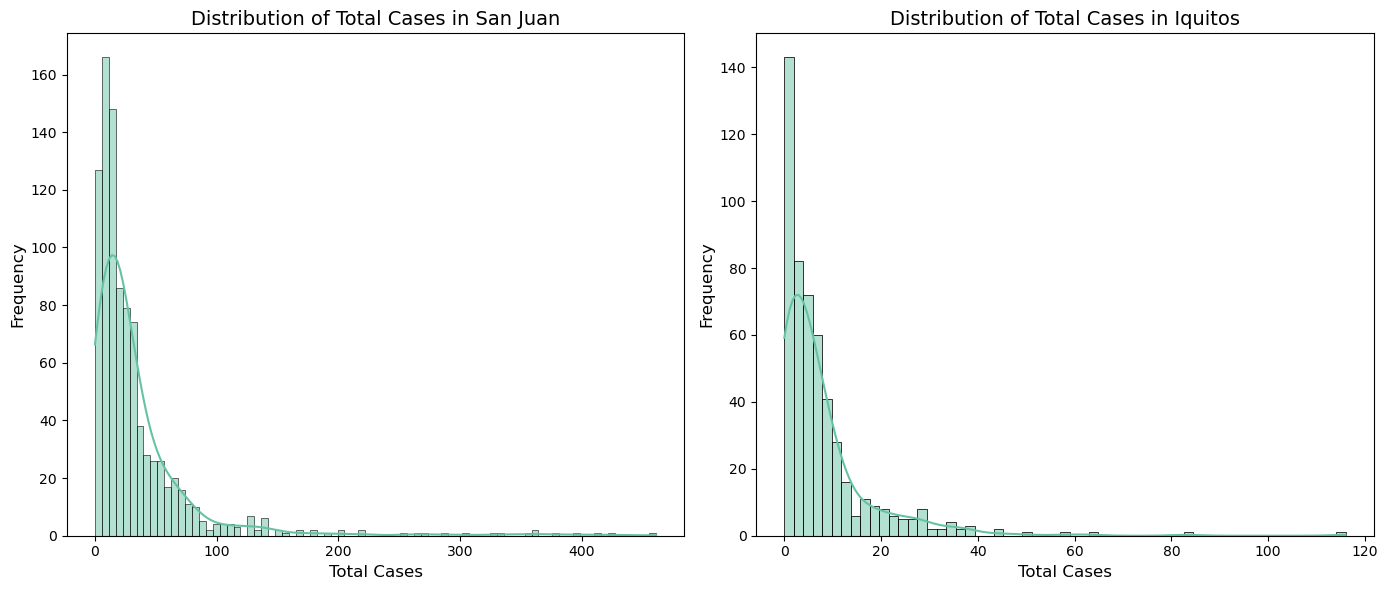

In [55]:
# plotting target variable distribution
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
sns.histplot(train_df[train_df['city'] == 'sj']['total_cases'], kde=True)
plt.title("Distribution of Total Cases in San Juan")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(train_df[train_df['city'] == 'iq']['total_cases'], kde=True)
plt.title("Distribution of Total Cases in Iquitos")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('total_cases_distribution.png')

### Missing Value Analysis

In [57]:
# Calculate missing values percentage
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_data = pd.DataFrame({
    "Missing values": train_df.isnull().sum(),
    "Percentage (%)": missing_percentage
})

missing_data = missing_data.sort_values('Percentage (%)', ascending=False)
print("\nMissing values analysis:")
print(missing_data[missing_data['Missing values'] > 0])


Missing values analysis:
                                       Missing values  Percentage (%)
ndvi_ne                                           194       13.324176
ndvi_nw                                            52        3.571429
station_diur_temp_rng_c                            43        2.953297
station_avg_temp_c                                 43        2.953297
ndvi_sw                                            22        1.510989
ndvi_se                                            22        1.510989
station_precip_mm                                  22        1.510989
station_max_temp_c                                 20        1.373626
station_min_temp_c                                 14        0.961538
reanalysis_sat_precip_amt_mm                       13        0.892857
precipitation_amt_mm                               13        0.892857
reanalysis_relative_humidity_percent               10        0.686813
reanalysis_max_air_temp_k                          10        0.6

<Figure size 800x600 with 0 Axes>

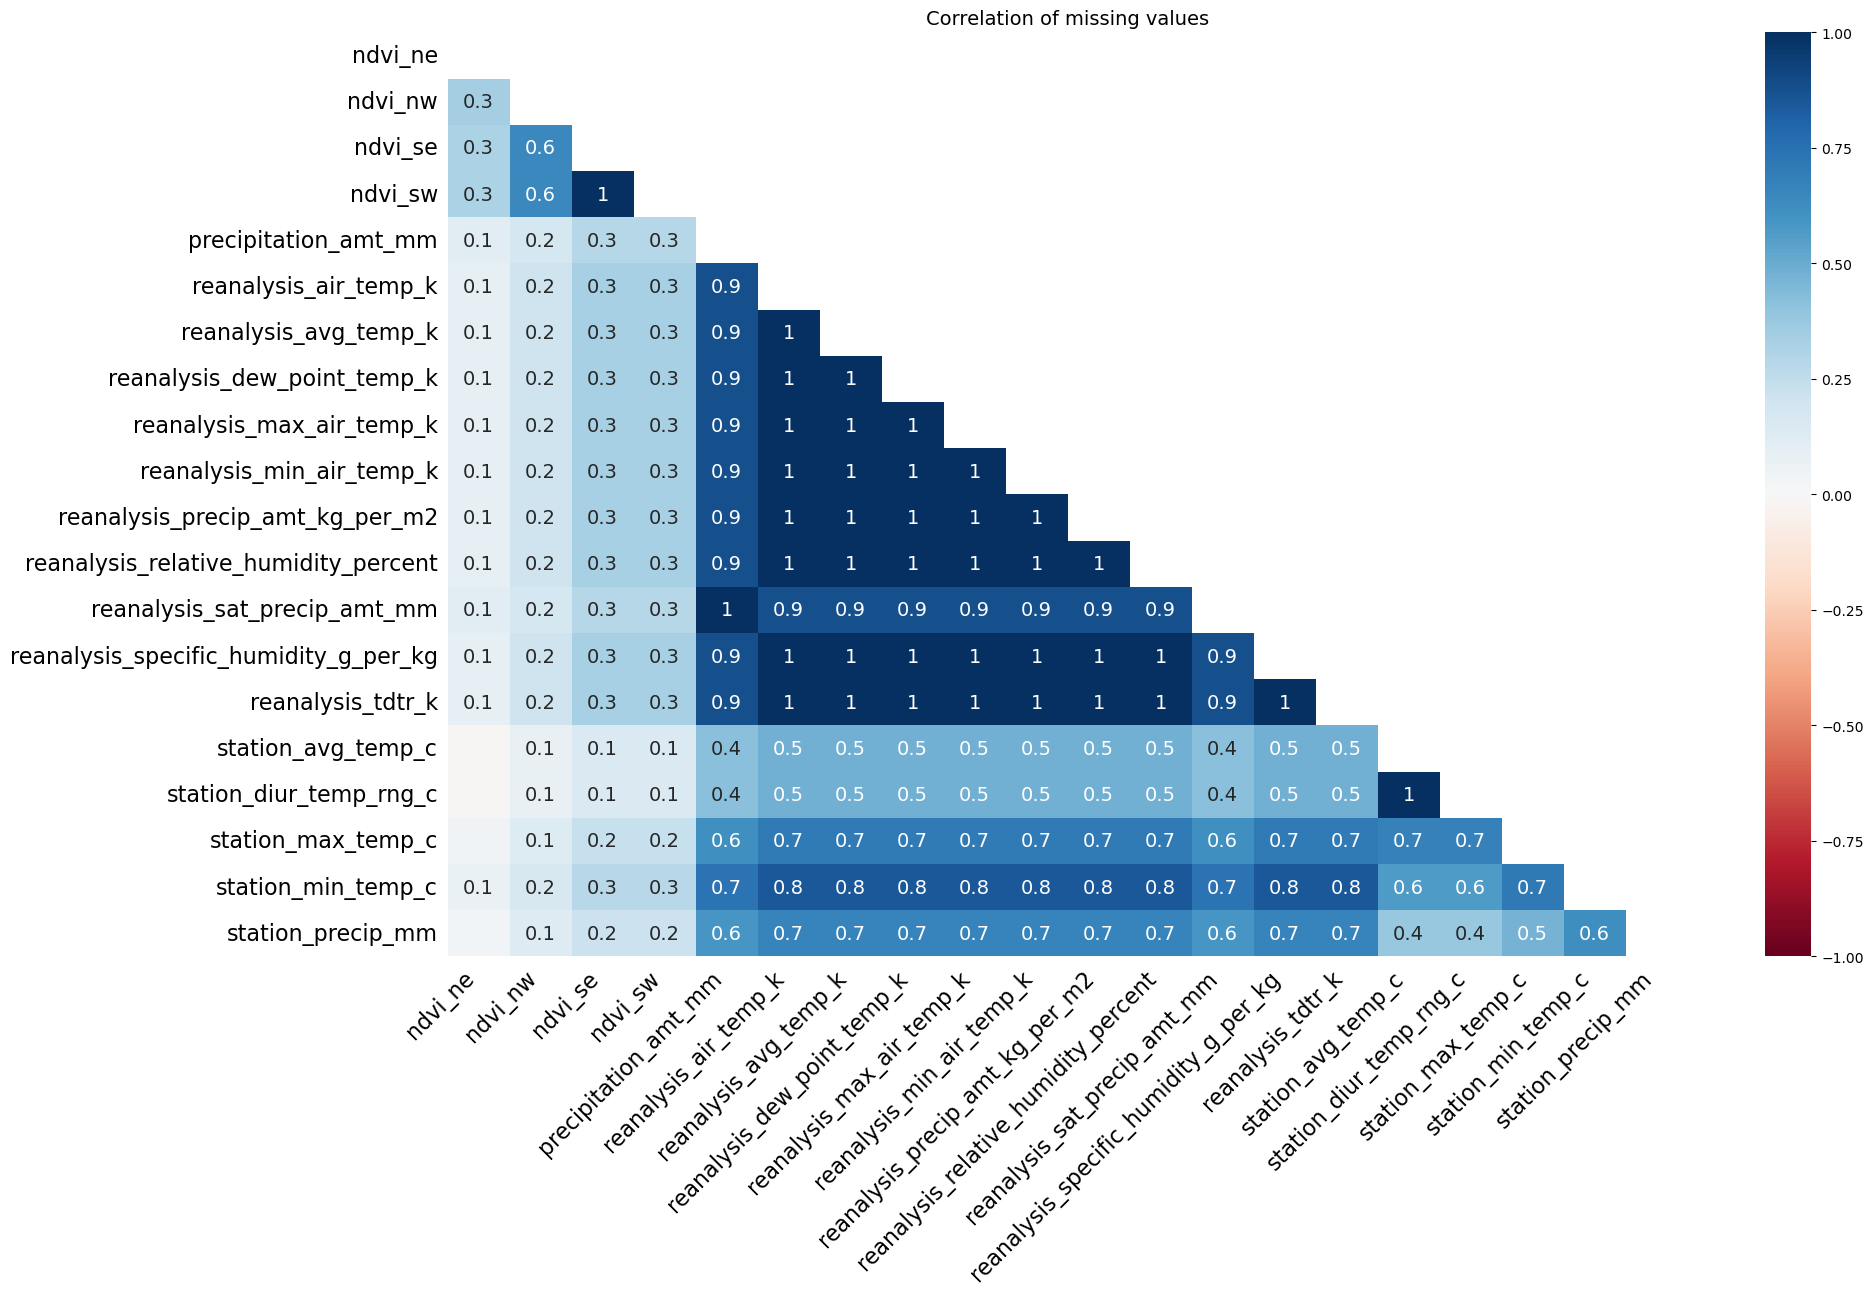

In [ ]:
# Plot missing values
plt.figure(figsize=(8, 6))
msno.heatmap(train_df)
plt.title("Correlation of missing values")
plt.savefig("_missing_values_heatmap.png");

In [61]:
# Set up time series data
sj_ts = train_df[train_df['city'] == 'sj'].sort_values('week_start_date')
iq_ts = train_df[train_df['city'] == 'iq'].sort_values('week_start_date')

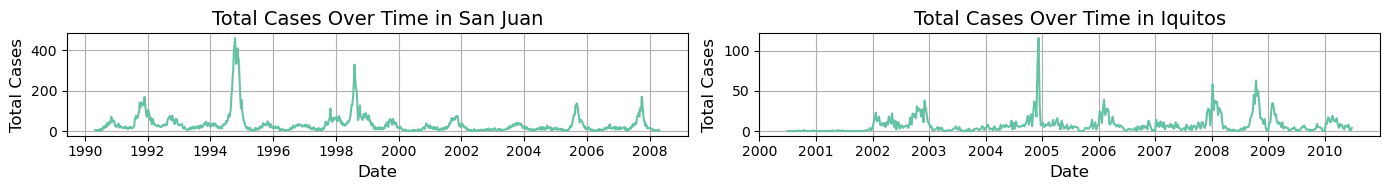

In [62]:
plt.figure(figsize=(14, 2))

plt.subplot(1, 2, 1)
plt.plot(sj_ts['week_start_date'], sj_ts['total_cases'])
plt.title('Total Cases Over Time in San Juan')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iq_ts['week_start_date'], iq_ts['total_cases'])
plt.title('Total Cases Over Time in Iquitos')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)

plt.tight_layout()
plt.savefig('total_cases_timeseries.png');

In [63]:
# Yearly and monthly patterns
# Group by year and week of year to see seasonal patterns
sj_yearly = sj_ts.groupby(['year', 'weekofyear'])['total_cases'].mean().reset_index()
sj_yearly_pivot = sj_yearly.pivot(index='weekofyear', columns='year', values='total_cases')

iq_yearly = iq_ts.groupby(['year', 'weekofyear'])['total_cases'].mean().reset_index()
iq_yearly_pivot = iq_yearly.pivot(index='weekofyear', columns='year', values='total_cases')

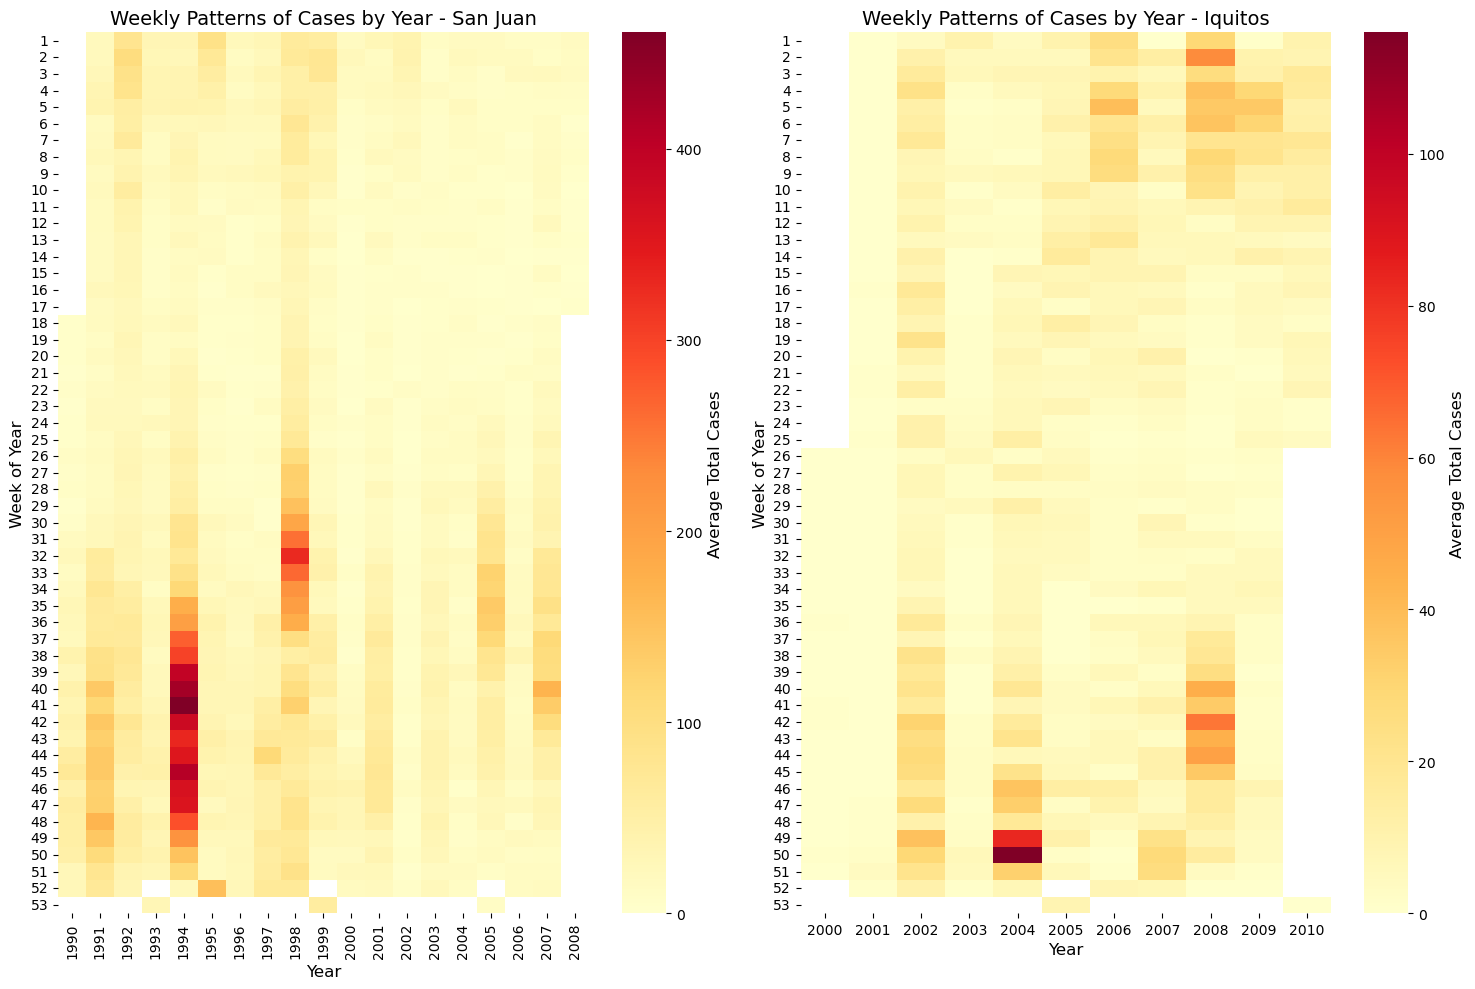

In [64]:
# plot yearly and monthly patterns
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
sns.heatmap(sj_yearly_pivot, cmap='YlOrRd', cbar_kws={'label': 'Average Total Cases'})
plt.title("Weekly Patterns of Cases by Year - San Juan")
plt.xlabel("Year")
plt.ylabel("Week of Year")

plt.subplot(1, 2, 2)
sns.heatmap(iq_yearly_pivot, cmap='YlOrRd', cbar_kws={'label': 'Average Total Cases'})
plt.title("Weekly Patterns of Cases by Year - Iquitos")
plt.xlabel("Year")
plt.ylabel("Week of Year")

plt.tight_layout()
plt.savefig('weekly_patterns_heatmap.png');


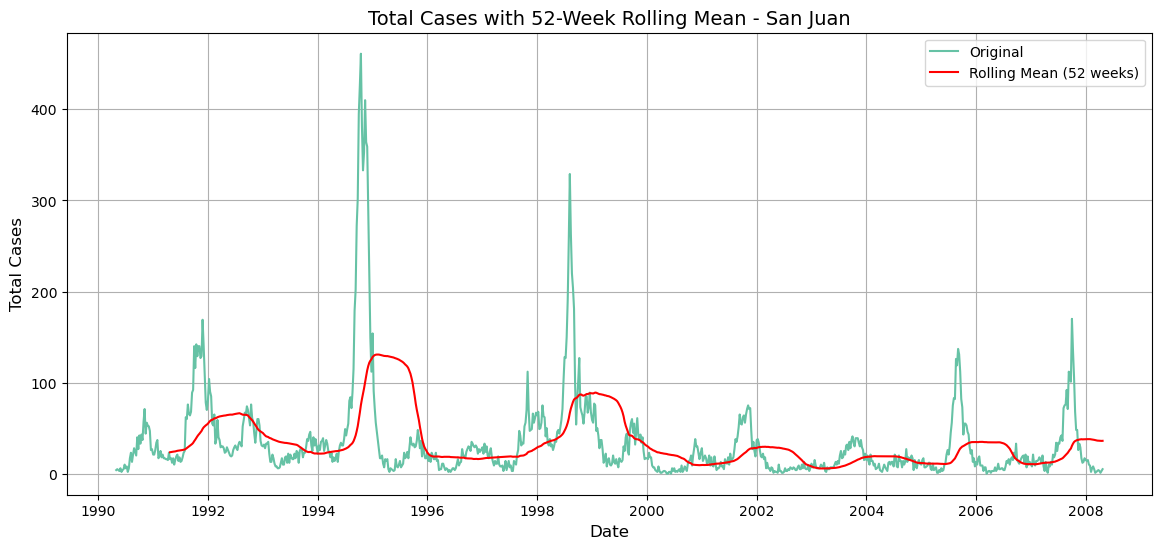

In [66]:
# Calculate rolling statistics for San Juan

if len(sj_ts) > 52:
    sj_rolling = sj_ts.set_index('week_start_date')["total_cases"].rolling(window=52).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(sj_ts['week_start_date'], sj_ts['total_cases'], label='Original')
    plt.plot(sj_rolling.index, sj_rolling.values, label='Rolling Mean (52 weeks)', color='red')
    plt.title('Total Cases with 52-Week Rolling Mean - San Juan')
    plt.xlabel('Date')
    plt.ylabel('Total Cases')
    plt.legend()
    plt.grid(True)
    plt.savefig('sj_rolling_mean.png');

In [68]:
# Select numeric features for analysis
numeric_features = train_df.select_dtypes(include=[np.number]).columns.to_list()
numeric_features.remove('total_cases')
numeric_features.remove('year')
numeric_features.remove('weekofyear')

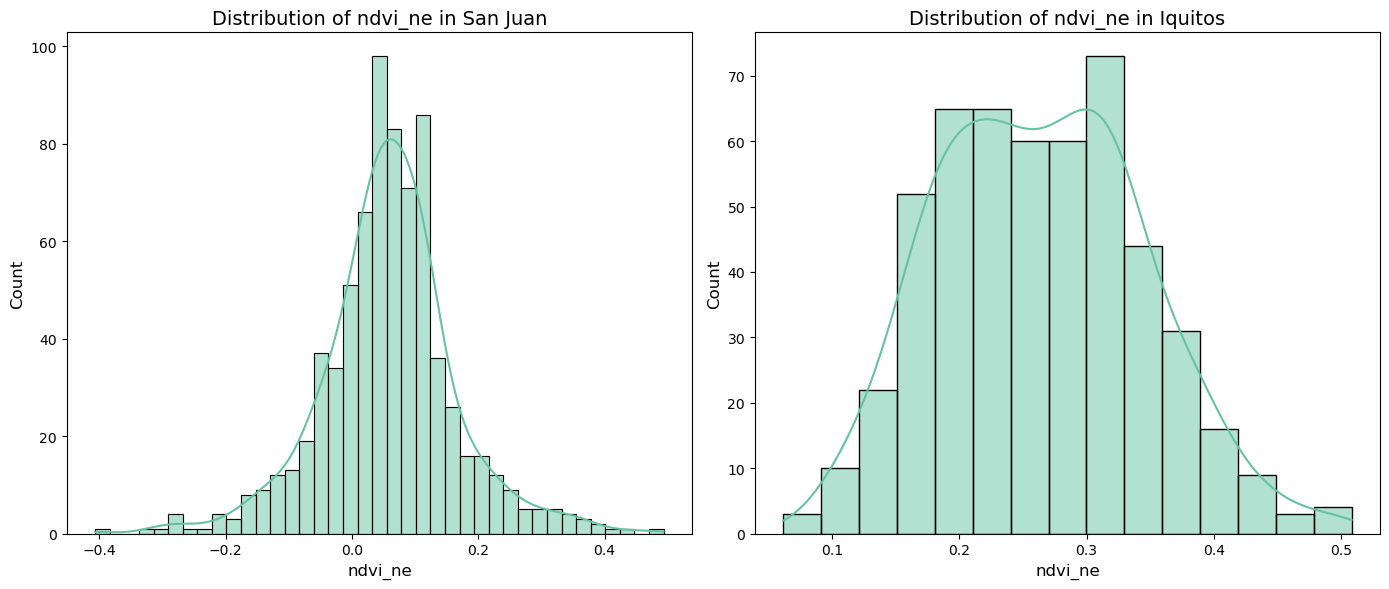

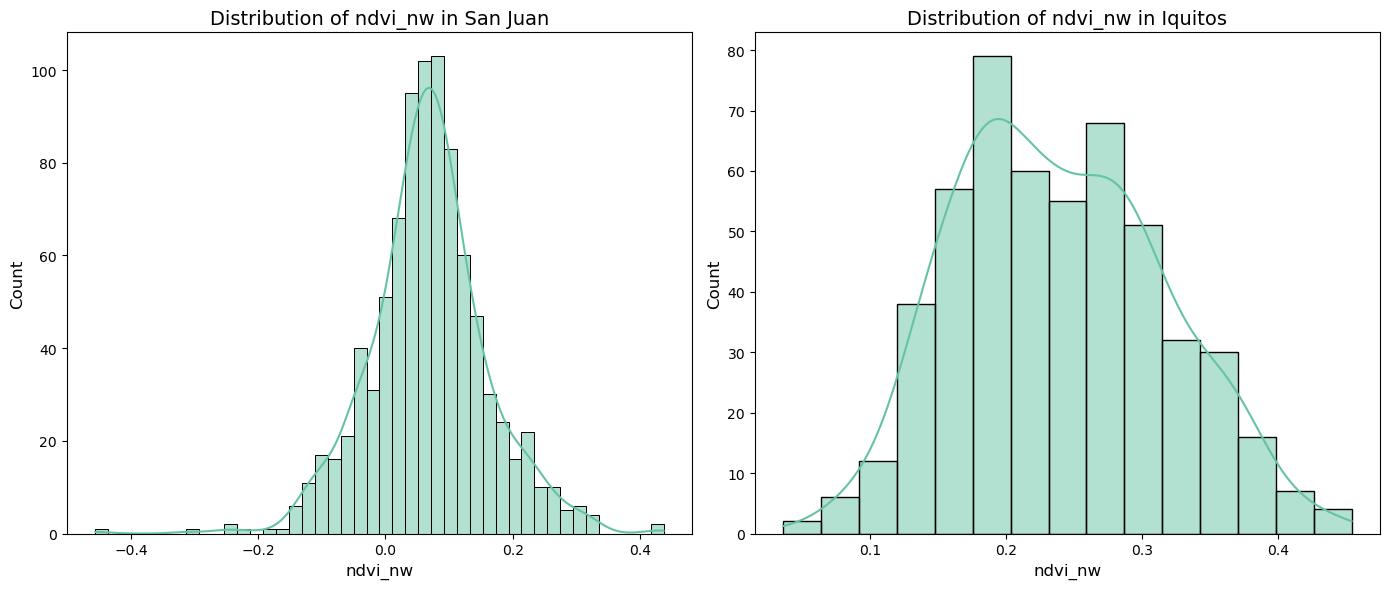

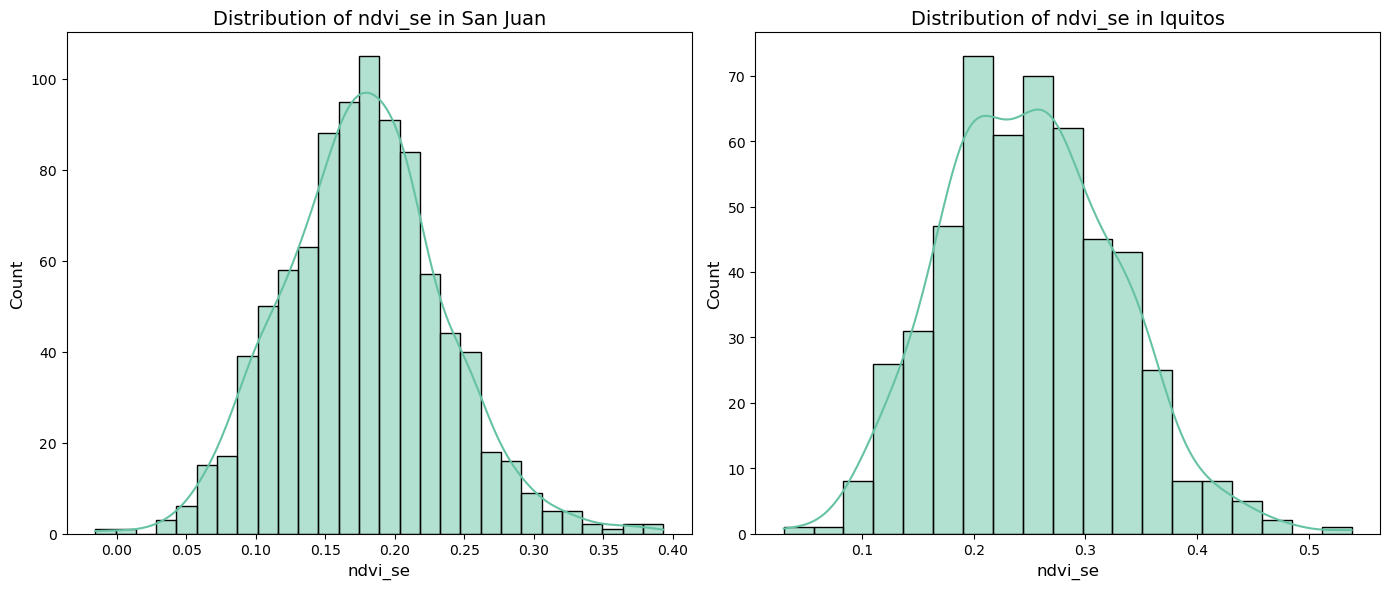

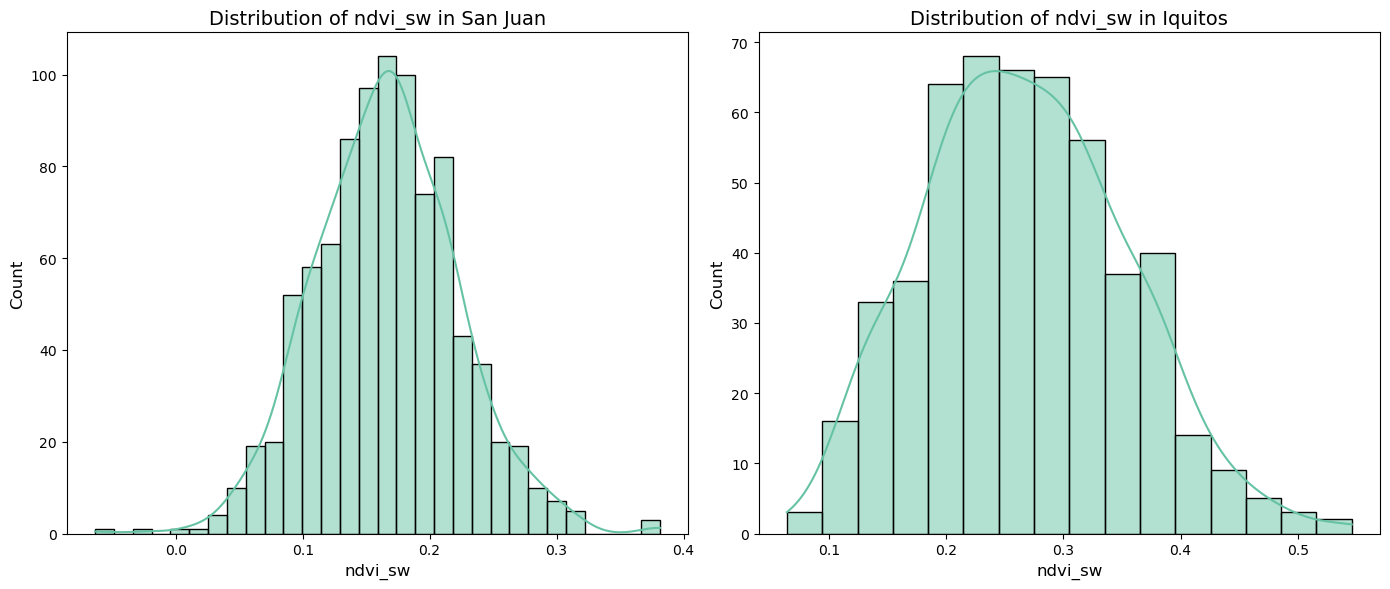

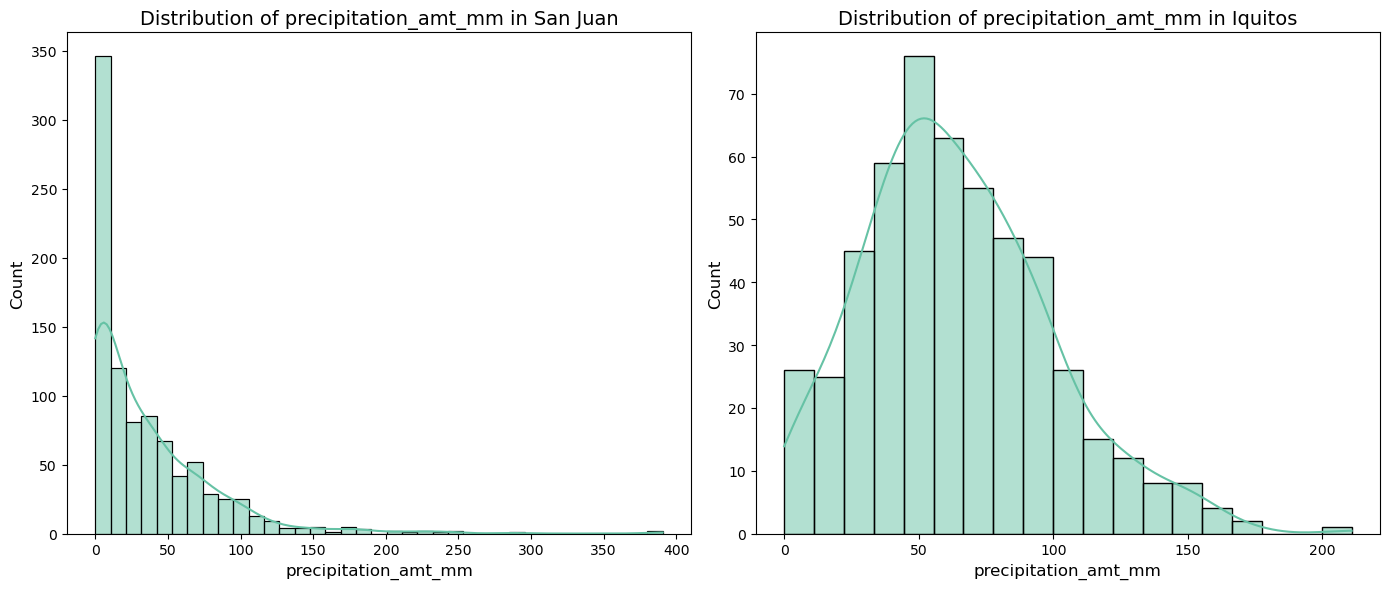

In [ ]:
# Create histograms for each numeric feature by city
for feature in numeric_features[:5]:
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[train_df['city'] == 'sj'][feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature} in San Juan')
    plt.xlabel(feature)
    
    plt.subplot(1, 2, 2)
    sns.histplot(train_df[train_df['city'] == 'iq'][feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature} in Iquitos')
    plt.xlabel(feature)
    
    plt.tight_layout()
    plt.savefig(f'{feature}_distribution.png');